In [148]:
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
## make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from statsforecast.models import TBATS
from statsforecast import StatsForecast
from prophet import Prophet
from pmdarima import auto_arima


def plot_results(y_to_train,
                 y_to_test, y_forecast,
                 plot_conf_int=True,
                 left_bound=None, right_bound=None):

    plt.plot(y_to_train, label='train')
    plt.plot(y_to_test, label='test')
    plt.plot(y_to_test.index, y_forecast, label='prediction')

    if plot_conf_int:
        plt.fill_between(y_to_test.index,
                         left_bound, right_bound,
                         alpha=0.23, color='grey',
                         label='intervals')
    plt.legend()
    plt.show()

## Prophet, SARIMAX, TBATS — модели для предсказания временных рядов

### 1. Задача

Рассмотрим [датасет](https://www.kaggle.com/c/demand-forecasting-kernels-only/overview) с kaggle с соревнования по прогнозированию спроса на товары.

In [149]:
data = pd.read_csv('train.csv', parse_dates=['date'])
data.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [150]:
store, item = 1,1
data = data[(data['store'] == store) & (data['item'] == item)]
data = data.set_index('date')
data = data['sales']

In [151]:
data.head()

date
2013-01-01    13
2013-01-02    11
2013-01-03    14
2013-01-04    13
2013-01-05    10
Name: sales, dtype: int64

### 2. Данные
Разделим данные на train и test. test — данные за последний год.

In [152]:
test_size = 365
data_train = data.iloc[: -test_size]
data_test  = data.iloc[-test_size:]

Визуализируем данные.

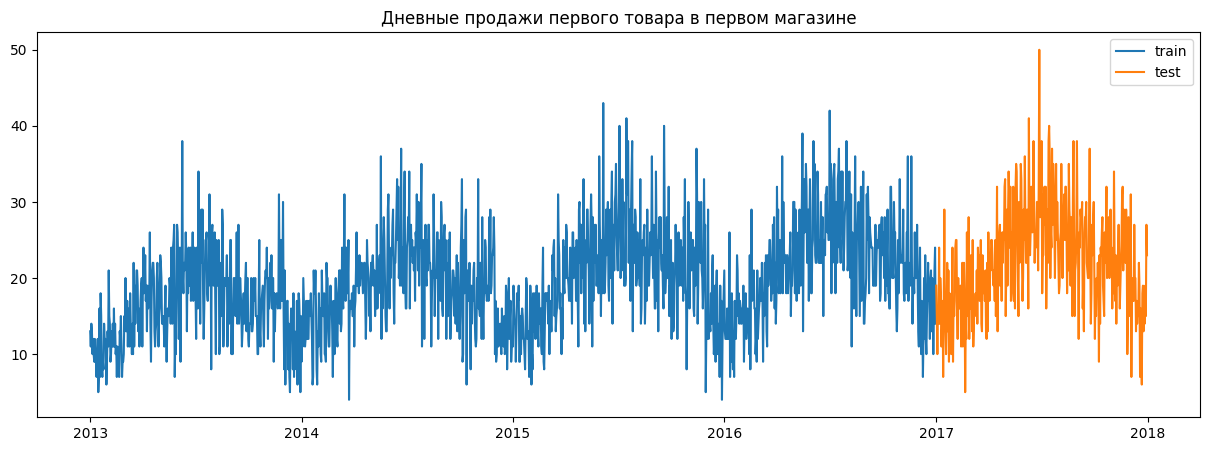

In [153]:
plt.figure(figsize=(15, 5))

plt.title('Дневные продажи первого товара в первом магазине')

plt.plot(data_train, label='train')
plt.plot(data_test, label='test')
plt.legend()

Некоторая недельная сезонность есть.

### 3. Метрики
Зададим метрики качества моделей: MSE, MAE, MAPE. Зададим функцию, которая будет вычислять метрики качества моделей и записывать их в таблицу.


- MAPE (Mean Absolute Percentage Error) поможет оценить, насколько близки прогнозы к фактическим значениям в процентном соотношении.
- 	MSE (Mean Squared Error) — для измерения среднеквадратичной ошибки между прогнозами и фактическими значениями. Это поможет понять среднюю ошибку прогноза в квадрате.
- 	MAE (Mean Absolute Error) — для оценки средней абсолютной ошибки между прогнозами и реальными значениями. Хорошо интерпретируется и проста в использовании.

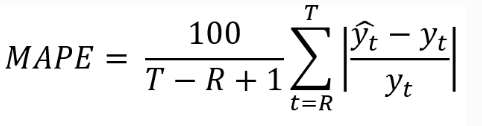

In [154]:
# MAPE
def mean_absolute_percentage_error(y_true, y_pred) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [155]:
def add_method_comparison(method: str, y_true, y_forecast, compare_table=None) -> pd.DataFrame:
    result_row = {
        'method': method,
        "MSE": mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE": mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE": mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast)
    }

    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
    return compare_table



### 4. Prophet

###4.1. Prophet

Prophet — модель для предсказания временных рядов, разработанная «Фейсбуком»*.

*Деятельность компании Meta Platforms Inc., которой принадлежит указаная соцсеть и сервис, признана экстремистской и запрещена на территории РФ.

In [156]:
prophet_train_df = pd.DataFrame(data_train)

prophet_train_df.columns = ['y']
prophet_train_df['ds'] = prophet_train_df.index

In [157]:
prophet_train_df

,y,ds
date,,
2013-01-01,13,2013-01-01
2013-01-02,11,2013-01-02
2013-01-03,14,2013-01-03
2013-01-04,13,2013-01-04
2013-01-05,10,2013-01-05
...,...,...
2016-12-27,10,2016-12-27
2016-12-28,16,2016-12-28
2016-12-29,21,2016-12-29


In [158]:
prophet_model = Prophet(interval_width=0.95)
prophet_model.fit(prophet_train_df)

future = prophet_model.make_future_dataframe(
    periods=test_size, include_history=False
)

y_prophet_forecast = prophet_model.predict(future)

In [159]:
y_prophet_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,22.655342,12.678916,29.776863,22.655342,22.655342,-1.504664,-1.504664,-1.504664,3.723695,3.723695,3.723695,-5.228358,-5.228358,-5.228358,0.0,0.0,0.0,21.150678
1,2017-01-02,22.659391,5.029435,21.131601,22.659391,22.659391,-9.438411,-9.438411,-9.438411,-4.232829,-4.232829,-4.232829,-5.205583,-5.205583,-5.205583,0.0,0.0,0.0,13.220979
2,2017-01-03,22.663439,7.452268,24.353464,22.663435,22.663439,-6.835885,-6.835885,-6.835885,-1.635984,-1.635984,-1.635984,-5.199901,-5.199901,-5.199901,0.0,0.0,0.0,15.827555
3,2017-01-04,22.667488,7.620083,24.869892,22.667457,22.667490,-6.324697,-6.324697,-6.324697,-1.114473,-1.114473,-1.114473,-5.210224,-5.210224,-5.210224,0.0,0.0,0.0,16.342791
4,2017-01-05,22.671536,8.599306,25.525286,22.671479,22.671554,-5.942764,-5.942764,-5.942764,-0.707770,-0.707770,-0.707770,-5.234994,-5.234994,-5.234994,0.0,0.0,0.0,16.728773


Модель для каждой даты раскладывает своё предсказание на компоненты.

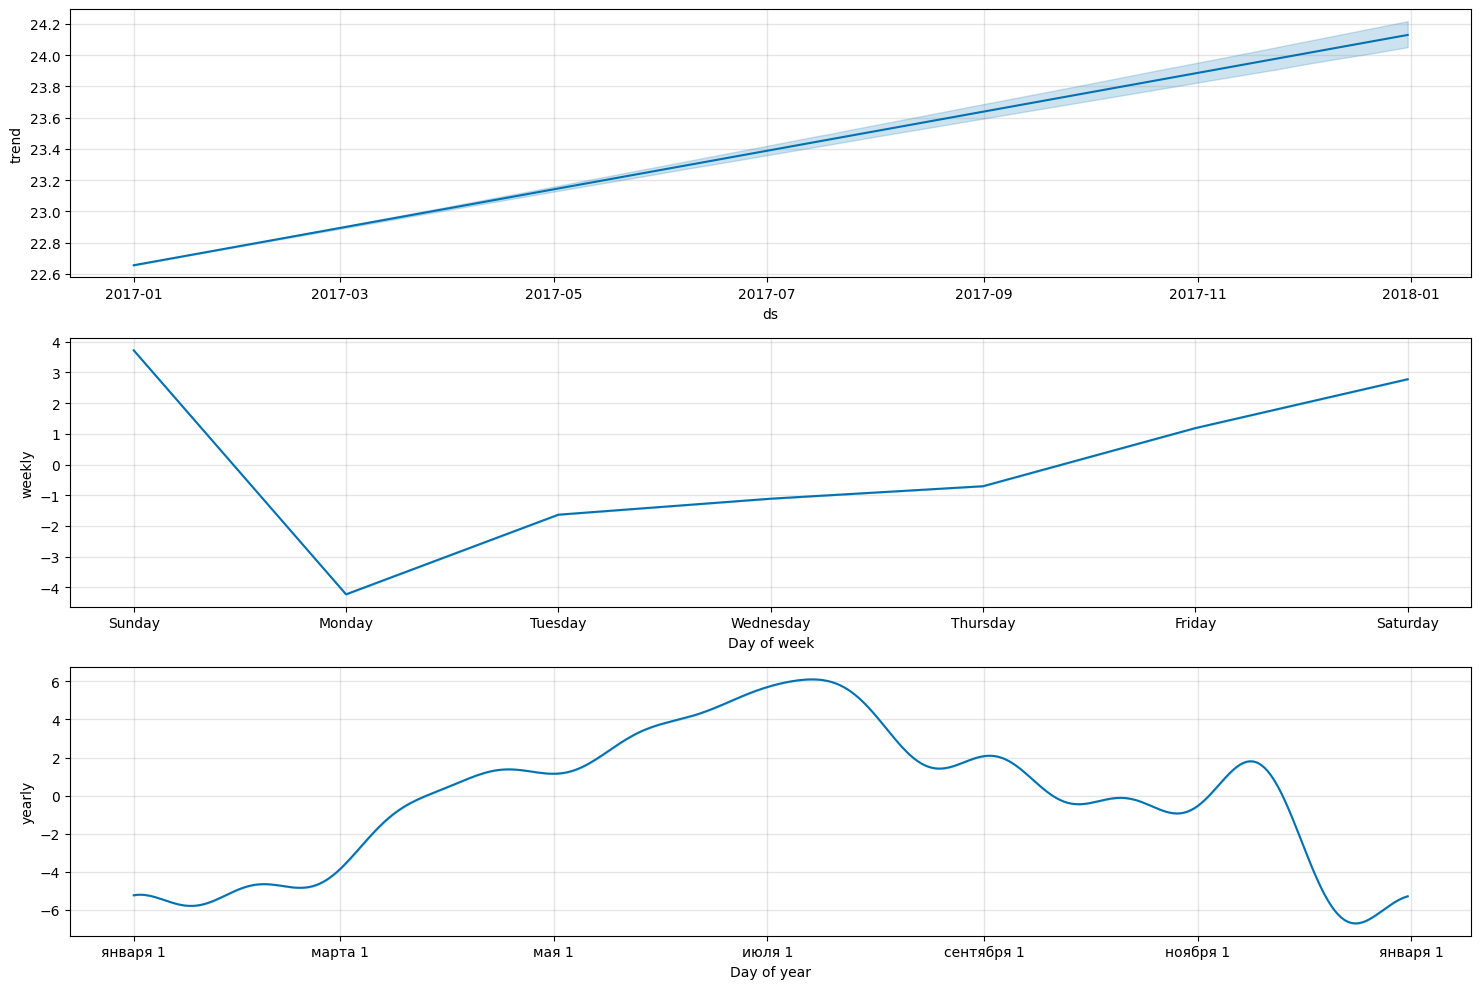

In [160]:
prophet_model.plot_components(y_prophet_forecast, figsize=(15, 10))
plt.show()

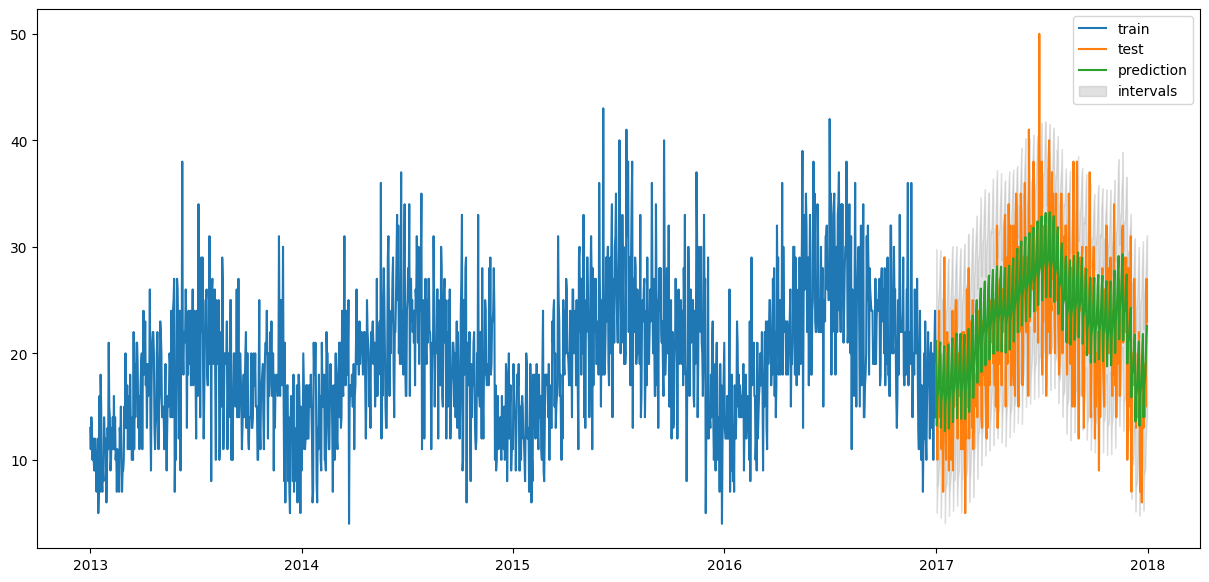

In [161]:
plot_results(data_train, data_test, y_prophet_forecast['yhat'], plot_conf_int=True,
             left_bound=y_prophet_forecast['yhat_lower'],
             right_bound=y_prophet_forecast['yhat_upper'])

In [162]:
compare_table = add_method_comparison('Prophet', data_test, y_prophet_forecast['yhat'])
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.680312,4.032058,22.233162


#### **Задание**
- Обучите модель Prophet с учётом праздников США — *Prophet + US holidays*.
- Преобразование Бокса — Кокса: обучите модель Prophet на преобразованном таргете — *Prophet*:
    - сделайте прямое преобразование над таргетом sps.boxcox(y);
    - потом сделайте обратное (нужно написать самостоятельно).

### 4.2. Prophet + US holidays

In [163]:
import itertools
import logging
# Отключаем подробный вывод Prophet и cmdstanpy
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

prophet_train_df = pd.DataFrame(data_train)
prophet_train_df.columns = ['y']
prophet_train_df['ds'] = prophet_train_df.index

param_grid = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'holidays_prior_scale': [10.0, 20.0, 30.0],
    'changepoint_range': [0.9, 0.95],  # НОВОЕ
    'n_changepoints': [20, 25, 30]     # НОВОЕ - убраны слишком маленькие значения
}

best_params = None
best_score = float('inf')
results = []

print("Начинаем грубый поиск...")

for params in itertools.product(*param_grid.values()):
    param_dict = dict(zip(param_grid.keys(), params))
    
    try:
        model = Prophet(**param_dict, interval_width=0.95)
        model.add_country_holidays(country_name='US')
        model.fit(prophet_train_df)
        
        future = model.make_future_dataframe(periods=test_size, include_history=False)
        forecast = model.predict(future)
        
        mape = mean_absolute_percentage_error(data_test, forecast['yhat'])
        results.append((param_dict, mape))
        
        if mape < best_score:
            best_score = mape
            best_params = param_dict
            
    except Exception as e:
        print(f"Error with params {param_dict}: {e}")
        continue

print(f"Best params: {best_params}, MAPE: {best_score}")

# Refinement search
print("Начинаем refinement search...")
refined_grid = {
    'seasonality_mode': [best_params['seasonality_mode']],
    'changepoint_prior_scale': np.linspace(max(0.001, best_params['changepoint_prior_scale']-0.2), 
                                          best_params['changepoint_prior_scale']+0.2, 5),
    'seasonality_prior_scale': np.linspace(max(0.1, best_params['seasonality_prior_scale']-2.0), 
                                          best_params['seasonality_prior_scale']+2.0, 5),
    'holidays_prior_scale': np.linspace(max(0.1, best_params['holidays_prior_scale']-2.0), 
                                       best_params['holidays_prior_scale']+2.0, 5),
    'changepoint_range': [best_params['changepoint_range'] - 0.05, best_params['changepoint_range'], 
                         best_params['changepoint_range'] + 0.05] if 'changepoint_range' in best_params else [0.8, 0.9],
    'n_changepoints': [best_params['n_changepoints'] - 5, best_params['n_changepoints'], 
                       best_params['n_changepoints'] + 5] if 'n_changepoints' in best_params else [20, 25, 30]
}

refined_results = []

for params in itertools.product(*refined_grid.values()):
    param_dict = dict(zip(refined_grid.keys(), params))
    
    try:
        model = Prophet(**param_dict, interval_width=0.95)
        model.add_country_holidays(country_name='US')
        model.fit(prophet_train_df)
        
        future = model.make_future_dataframe(periods=test_size, include_history=False)
        forecast = model.predict(future)
        
        mape = mean_absolute_percentage_error(data_test, forecast['yhat'])
        refined_results.append((param_dict, mape))
        
    except Exception as e:
        continue

# Сортировка и выбор 5 лучших
refined_results.sort(key=lambda x: x[1])
top_5_prophet = refined_results[:5]

print(f"Топ-5 параметров: {top_5_prophet}")

# ВЗВЕШЕННЫЙ Ансамбль (улучшенный)
print("Начинаем взвешенное ансамблирование...")

# Вычисляем веса обратно пропорционально MAPE
weights = [1/mape for _, mape in top_5_prophet]
weights = np.array(weights) / sum(weights)

ensemble_forecast = np.zeros(len(data_test))

for i, (params, _) in enumerate(top_5_prophet):
    model = Prophet(**params, interval_width=0.95)
    model.add_country_holidays(country_name='US')
    model.fit(prophet_train_df)
    
    future = model.make_future_dataframe(periods=test_size, include_history=False)
    forecast = model.predict(future)
    
    # Умножаем на вес
    ensemble_forecast += weights[i] * forecast['yhat'].values

# Оценка ансамбля
ensemble_mape = mean_absolute_percentage_error(data_test, ensemble_forecast)
print(f"Prophet ensemble MAPE (weighted): {ensemble_mape}")

# Добавление в сравнительную таблицу
compare_table = add_method_comparison('Prophet + US holidays', data_test, ensemble_forecast, compare_table)
print("Prophet + US holidays добавлен в таблицу сравнения")

Начинаем грубый поиск...
Best params: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 30.0, 'changepoint_range': 0.9, 'n_changepoints': 20}, MAPE: 19.513164170785423
Начинаем refinement search...
Топ-5 параметров: [({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0.7), 'seasonality_prior_scale': np.float64(0.1), 'holidays_prior_scale': np.float64(28.0), 'changepoint_range': 0.85, 'n_changepoints': 15}, np.float64(19.462309820677234)), ({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0.7), 'seasonality_prior_scale': np.float64(3.0), 'holidays_prior_scale': np.float64(31.0), 'changepoint_range': 0.85, 'n_changepoints': 15}, np.float64(19.4660381884263)), ({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0.7), 'seasonality_prior_scale': np.float64(1.55), 'holidays_prior_scale': np.float64(30.0), 'changepoint_range': 0.85, 'n_changepoints': 15}, np.fl

### 4.3. Prophet. Преобразование Бокса — Кокса

In [164]:
from scipy import stats

# Преобразование Бокса-Кокса
transformed_y, lambda_param = stats.boxcox(data_train + 1)  # +1 чтобы избежать нулей
transformed_train_df = pd.DataFrame({'y': transformed_y, 'ds': prophet_train_df['ds']})

# ВАРИАНТ: Рекомендуемая сетка (по аналогии с Prophet + US holidays)
param_grid_bc = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'changepoint_range': [0.9, 0.95],  # НОВОЕ
    'n_changepoints': [20, 25, 30]     # НОВОЕ
}

best_params_bc = None
best_score_bc = float('inf')
results_bc = []

print("Начинаем грубый поиск для Prophet с Боксом-Коксом...")

for params in itertools.product(*param_grid_bc.values()):
    param_dict = dict(zip(param_grid_bc.keys(), params))
    
    try:
        model = Prophet(**param_dict, interval_width=0.95)
        model.fit(transformed_train_df)
        
        future = model.make_future_dataframe(periods=test_size, include_history=False)
        forecast = model.predict(future)
        
        # Обратное преобразование Бокса-Кокса
        yhat_transformed = forecast['yhat']
        yhat_original = np.power(lambda_param * yhat_transformed + 1, 1/lambda_param) - 1
        
        mape = mean_absolute_percentage_error(data_test, yhat_original)
        results_bc.append((param_dict, mape))
        
        if mape < best_score_bc:
            best_score_bc = mape
            best_params_bc = param_dict
            
    except Exception as e:
        print(f"Error with params {param_dict}: {e}")
        continue

print(f"Best params: {best_params_bc}, MAPE: {best_score_bc}")

# Refinement search
print("Начинаем refinement search для Prophet с Боксом-Коксом...")
refined_grid_bc = {
    'seasonality_mode': [best_params_bc['seasonality_mode']],
    'changepoint_prior_scale': np.linspace(max(0.001, best_params_bc['changepoint_prior_scale']-0.2), 
                                          best_params_bc['changepoint_prior_scale']+0.2, 5),
    'seasonality_prior_scale': np.linspace(max(0.1, best_params_bc['seasonality_prior_scale']-2.0), 
                                          best_params_bc['seasonality_prior_scale']+2.0, 5),
    'changepoint_range': [best_params_bc['changepoint_range'] - 0.05, best_params_bc['changepoint_range'], 
                         best_params_bc['changepoint_range'] + 0.05] if 'changepoint_range' in best_params_bc else [0.8, 0.9],
    'n_changepoints': [best_params_bc['n_changepoints'] - 5, best_params_bc['n_changepoints'], 
                       best_params_bc['n_changepoints'] + 5] if 'n_changepoints' in best_params_bc else [20, 25, 30]
}

refined_results_bc = []

for params in itertools.product(*refined_grid_bc.values()):
    param_dict = dict(zip(refined_grid_bc.keys(), params))
    
    try:
        model = Prophet(**param_dict, interval_width=0.95)
        model.fit(transformed_train_df)
        
        future = model.make_future_dataframe(periods=test_size, include_history=False)
        forecast = model.predict(future)
        
        # Обратное преобразование Бокса-Кокса
        yhat_transformed = forecast['yhat']
        yhat_original = np.power(lambda_param * yhat_transformed + 1, 1/lambda_param) - 1
        
        mape = mean_absolute_percentage_error(data_test, yhat_original)
        refined_results_bc.append((param_dict, mape))
        
    except Exception as e:
        continue

# Сортировка и выбор 5 лучших
refined_results_bc.sort(key=lambda x: x[1])
top_5_prophet_bc = refined_results_bc[:5]

print(f"Топ-5 параметров: {top_5_prophet_bc}")

# ВЗВЕШЕННЫЙ Ансамбль (улучшенный)
print("Начинаем взвешенное ансамблирование для Prophet с Боксом-Коксом...")

# Вычисляем веса обратно пропорционально MAPE
weights = [1/mape for _, mape in top_5_prophet_bc]
weights = np.array(weights) / sum(weights)

ensemble_forecast_bc = np.zeros(len(data_test))

for i, (params, _) in enumerate(top_5_prophet_bc):
    model = Prophet(**params, interval_width=0.95)
    model.fit(transformed_train_df)
    
    future = model.make_future_dataframe(periods=test_size, include_history=False)
    forecast = model.predict(future)
    
    # Обратное преобразование Бокса-Кокса
    yhat_transformed = forecast['yhat']
    yhat_original = np.power(lambda_param * yhat_transformed + 1, 1/lambda_param) - 1
    
    # Умножаем на вес
    ensemble_forecast_bc += weights[i] * yhat_original

# Оценка ансамбля
ensemble_mape_bc = mean_absolute_percentage_error(data_test, ensemble_forecast_bc)
print(f"Prophet BC ensemble MAPE (weighted): {ensemble_mape_bc}")

# Добавление в сравнительную таблицу
compare_table = add_method_comparison('Prophet + Box-Cox', data_test, ensemble_forecast_bc, compare_table)
print("Prophet + Box-Cox добавлен в таблицу сравнения")

Начинаем грубый поиск для Prophet с Боксом-Коксом...
Best params: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'changepoint_range': 0.95, 'n_changepoints': 20}, MAPE: 20.213221916513884
Начинаем refinement search для Prophet с Боксом-Коксом...
Топ-5 параметров: [({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0.7), 'seasonality_prior_scale': np.float64(3.0), 'changepoint_range': 1.0, 'n_changepoints': 15}, np.float64(19.51457268409135)), ({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0.7), 'seasonality_prior_scale': np.float64(0.1), 'changepoint_range': 1.0, 'n_changepoints': 15}, np.float64(19.585816030570278)), ({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0.7), 'seasonality_prior_scale': np.float64(0.825), 'changepoint_range': 1.0, 'n_changepoints': 25}, np.float64(19.59655548178524)), ({'seasonality_mode': 'additive', 'changepoint_prior_scale': np.float64(0

### 5. AutoARIMA [without exog]

### 5.1. AutoARIMA [without exog]

In [165]:
arima_model = auto_arima(data_train, seasonal=True, m = 7)

In [166]:
y_arima_forecast, conf_int = arima_model.predict(n_periods=test_size, return_conf_int=True, alpha=0.05)

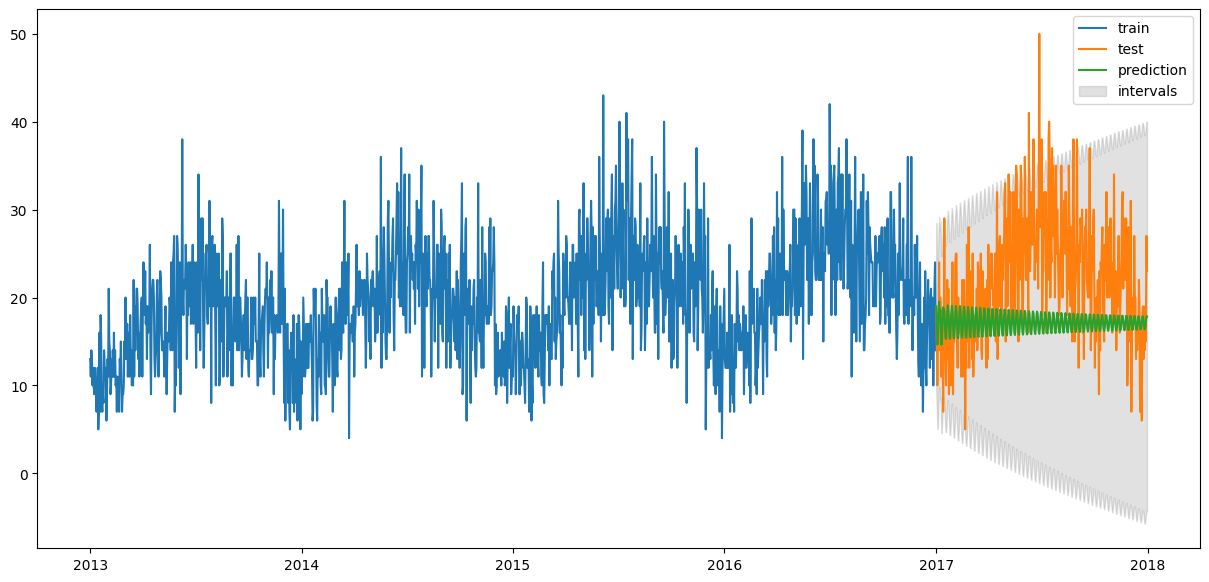

In [167]:
plot_results(data_train, data_test, y_arima_forecast, plot_conf_int=True,
             left_bound=conf_int.T[0],
             right_bound=conf_int.T[1])

In [168]:
compare_table = add_method_comparison('Auto arima model', data_test, y_arima_forecast, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.680312,4.032058,22.233162
1,Prophet + US holidays,24.654072,3.927995,19.468621
2,Prophet + Box-Cox,23.312855,3.845734,19.589358
3,Auto arima model,70.938615,6.648390,28.906985


### 5.2. AutoARIMA exog

In [169]:
exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

exog = exog.drop(columns=['date'])

exog_to_train = exog.iloc[:-test_size]
exog_to_test = exog.iloc[-test_size:]

todo: используйте модель `auto_arima` с экзогенными переменными, которые созданы выше (их не надо менять).

Посчитайте метрики качества и добавьте их в датафрейм (сравнительную таблицу) с метриками по всем обученным до этого моделям.

In [185]:
arima_model = auto_arima(
    data_train,
    seasonal=True,
    m=7,                       # недельная сезонность
    stepwise=True,             # ускорение поиска
    trace=False,               
    error_action='ignore',     
    suppress_warnings=True,
    D=1,                       # порядок сезонной дифференциации
    d=None,                    # автоматический подбор
    p=(1,2,3),                 # диапазон p
    q=(1,2,3),                 # диапазон q
    P=(0,1,2),                 # диапазон P
    Q=(0,1,2),                 # диапазон Q
    max_p=5,                   # максимальное p
    max_q=5,                   # максимальное q
    max_P=3,                   # максимальное P
    max_Q=3,                   # максимальное Q
    max_d=2,                   # максимальная d
    max_D=2,                   # максимальная D
    information_criterion='aic', # критерий выбора модели
    maxiter=100,
)

y_arima_forecast, conf_int = arima_model.predict(n_periods=test_size, exogenous=exog_to_test, return_conf_int=True, alpha=0.05)


# Оценка модели
ensemble_mape_arima = mean_absolute_percentage_error(data_test, y_arima_forecast)
print(f"AutoARIMA MAPE: {ensemble_mape_arima}")

# Добавление в сравнительную таблицу
compare_table = add_method_comparison('AutoARIMA + exog', data_test, y_arima_forecast, compare_table)
print("AutoARIMA + exog добавлен в таблицу сравнения")

AutoARIMA MAPE: 26.6530541625252
AutoARIMA + exog добавлен в таблицу сравнения


### 6. SARIMAX [without exog]

### 6.1. SARIMAX [without exog]

In [171]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# передаем параметры из прошлой модели
real_sarimax_model = SARIMAX(data_train, order=(3, 1, 5), seasonal_order=(0, 0, 2, 7),
    seasonal_periods=7,
    ).fit()


/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasonal_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

In [172]:
forecast = real_sarimax_model.get_forecast(steps=len(data_test))
y_sarimax_real_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()


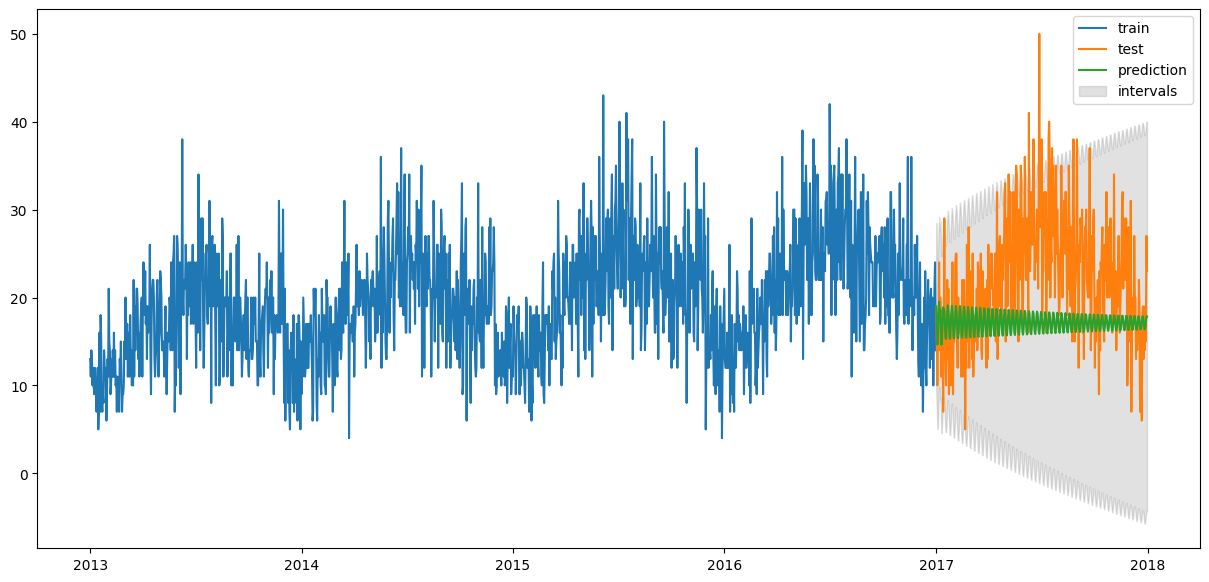

In [173]:
plot_results(data_train, data_test,
             y_sarimax_real_forecast, plot_conf_int=True,
             left_bound=conf_int['lower sales'], right_bound=conf_int['upper sales'])

In [174]:
compare_table = add_method_comparison('Original SARIMAX', data_test, y_sarimax_real_forecast, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.680312,4.032058,22.233162
1,Prophet + US holidays,24.654072,3.927995,19.468621
2,Prophet + Box-Cox,23.312855,3.845734,19.589358
3,Auto arima model,70.938615,6.648390,28.906985
4,AutoARIMA + exog,56.524328,5.880263,26.653054
5,Original SARIMAX,70.938615,6.648390,28.906985


### 6.2. SARIMAX with exog

In [175]:
exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

exog = exog.drop(columns=['date'])

exog_to_train = exog.iloc[:-test_size]
exog_to_test = exog.iloc[-test_size:]

todo: используйте модель `SARIMAX` с экзогенными переменными, которые созданы выше (их не надо менять), для улучшения предсказаний.

In [187]:
# SARIMAX с экзогенными переменными
print("Начинаем обучение SARIMAX с экзогенными переменными...")

# Пробуем более простые и устойчивые параметры
# Используем те же параметры, что дали хороший результат в Original SARIMAX (28.91%)
sarimax_model = SARIMAX(
    data_train,
    exog=exog_to_train,
    order=(3, 1, 5),           # те же параметры что дали 28.91% без exog
    seasonal_order=(0, 0, 2, 7),
    seasonal_periods=7,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast = sarimax_model.get_forecast(steps=len(data_test), exog=exog_to_test)
y_sarimax_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

# Оценка модели
ensemble_mape_sarimax = mean_absolute_percentage_error(data_test, y_sarimax_forecast)
print(f"SARIMAX MAPE: {ensemble_mape_sarimax}")

# Добавление в сравнительную таблицу
compare_table = add_method_comparison('SARIMAX + exog', data_test, y_sarimax_forecast, compare_table)
print("SARIMAX + exog добавлен в таблицу сравнения")

Начинаем обучение SARIMAX с экзогенными переменными...


/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasonal_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

SARIMAX MAPE: 23.888422091315487
SARIMAX + exog добавлен в таблицу сравнения


/home/stranger/PycharmProjects/ml-advanced/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasonal_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


### 7. TBATS

Модель учитывает несколько сезонностей, но не может принимать экзогенные признаки.

Начинаем grid search для TBATS...
Best params: {'season_length': [7, 365], 'use_boxcox': False, 'use_trend': True, 'use_damped_trend': True}, MAPE: 22.15027027218901


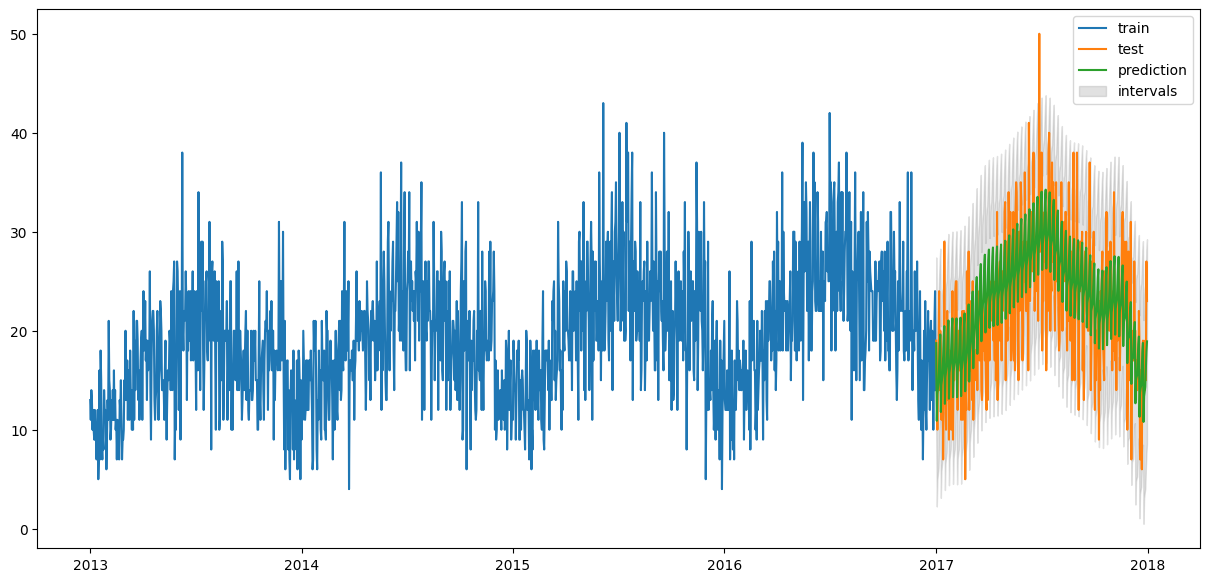

TBATS model добавлен в таблицу сравнения


In [188]:
import itertools

# Подготовка данных для StatsForecast
df_train = pd.DataFrame({
    'unique_id': ['series1'] * len(data_train),
    'ds': data_train.index,
    'y': data_train.values
})

# Grid search для TBATS
param_grid = {
    'season_length': [[7], [7, 30], [7, 365], [7, 30, 365]],
    'use_boxcox': [True, False],
    'use_trend': [True],
    'use_damped_trend': [True, False]
}

best_mape = float('inf')
best_params = None
best_forecast = None
results = []

print("Начинаем grid search для TBATS...")

for params in itertools.product(*param_grid.values()):
    param_dict = dict(zip(param_grid.keys(), params))
    
    try:
        tbats_estimator = StatsForecast(
            models=[TBATS(**param_dict)], 
            freq='D'
        )
        
        forecast_df = tbats_estimator.forecast(df=df_train, h=test_size, level=[95])
        mape = mean_absolute_percentage_error(data_test, forecast_df['TBATS'].values)
        
        results.append((param_dict, mape))
        
        if mape < best_mape:
            best_mape = mape
            best_params = param_dict
            best_forecast = forecast_df
            
    except Exception as e:
        print(f"Error with params {param_dict}: {e}")
        continue

print(f"Best params: {best_params}, MAPE: {best_mape}")

# Используем лучший прогноз
tbats_forecast = pd.Series(
    best_forecast['TBATS'].values, 
    index=best_forecast['ds']
)

confidence_info = {
    'lower_bound': best_forecast['TBATS-lo-95'].values,
    'upper_bound': best_forecast['TBATS-hi-95'].values
}

plot_results(data_train, data_test, tbats_forecast, plot_conf_int=True,
             left_bound=confidence_info['lower_bound'],
             right_bound=confidence_info['upper_bound'])

final_table = add_method_comparison('TBATS model', data_test, tbats_forecast, compare_table)
print("TBATS model добавлен в таблицу сравнения")

In [189]:
final_table

,method,MSE,MAE,MAPE
0,Prophet,24.680312,4.032058,22.233162
1,Prophet + US holidays,24.654072,3.927995,19.468621
2,Prophet + Box-Cox,23.312855,3.845734,19.589358
3,Auto arima model,70.938615,6.648390,28.906985
4,Original SARIMAX,70.938615,6.648390,28.906985
5,AutoARIMA + exog,56.524328,5.880263,26.653054
6,SARIMAX + exog,32.958298,4.541915,23.888422
7,TBATS model,25.013393,4.077535,22.150270


### 8. ИТОГО

todo:
- Опишите, что вы сделали в этой работе, какие параметры моделей подбирали и как.
- Сравните модели между собой и проанализируйте результаты.
- Выберите лучшую модель.

Метрика MAPE, которую нужно достичь (достаточно правильной настройки гиперпараметров моделей), должна быть менее 20%.

In [182]:
final_table

,method,MSE,MAE,MAPE
0,Prophet,24.680312,4.032058,22.233162
1,Prophet + US holidays,24.654072,3.927995,19.468621
2,Prophet + Box-Cox,23.312855,3.845734,19.589358
3,Auto arima model,70.938615,6.648390,28.906985
4,AutoARIMA + exog,56.524328,5.880263,26.653054
5,Original SARIMAX,70.938615,6.648390,28.906985
6,SARIMAX + exog,542.045950,22.193516,99.912728
7,TBATS model,27.379929,4.239593,23.064349


### Общий итог: подобрал наилучшие гиперпараметры моделей, частично - вручную, частично - с refinement grid search. Там, где это модель допускает, использовал также взвешенное ансамблирование. В результате в двух моделях Prophet добился требуемого уровня MAPE. Остальные модели до этого уровня не дотягивают. Отсюда делаю вывод, что на таком типе данных Prophet с улучшениями является наиболее эффективным. (Это не означает, что на других данных будет то же самое)